# Wczytanie danych

In [57]:
import pandas as pd
data = pd.read_csv("/content/drive/MyDrive/Dane/dane/bristol.csv", delimiter=";")
data.head()

,id,name,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,7746625,Period family friendly home,NaN,40719797,Victoria,"2015-08-06 00:00:00,000","Bristol, United Kingdom",NaN,NaN,NaN,...,5.00,4.75,5.00,4.50,f,1,1,0,0,0.11
1,9521652,"The Studio, 9 Old City Chambers",NaN,27954975,John,"2015-02-18 00:00:00,000","Bristol, United Kingdom",NaN,within an hour,100%,...,4.90,4.96,4.97,4.77,t,3,3,0,0,4.02
2,11515357,Cottage in Clifton Village,NaN,14130227,Anita,"2014-04-10 00:00:00,000","England, United Kingdom",NaN,NaN,NaN,...,4.99,4.97,4.98,4.75,f,1,1,0,0,1.00
3,14233480,Eaton Crescent - Beautiful Clifton Apartment,NaN,65463336,Michael,"2016-04-02 00:00:00,000","Bristol, United Kingdom",NaN,NaN,NaN,...,4.94,4.90,4.90,4.71,f,2,2,0,0,0.49
4,14483722,Central Bristol Budget Studio Apartment,NaN,45366780,Jake,"2015-09-29 00:00:00,000","Bristol, United Kingdom",NaN,within a few hours,100%,...,4.73,4.72,4.12,4.28,f,4,4,0,0,0.76


In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2845 entries, 0 to 2844
Data columns (total 65 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            2845 non-null   int64  
 1   name                                          2845 non-null   object 
 2   neighborhood_overview                         1392 non-null   object 
 3   host_id                                       2845 non-null   int64  
 4   host_name                                     2845 non-null   object 
 5   host_since                                    2845 non-null   object 
 6   host_location                                 2293 non-null   object 
 7   host_about                                    1662 non-null   object 
 8   host_response_time                            2345 non-null   object 
 9   host_response_rate                            2345 non-null   o

In [59]:
data = data.drop(columns=['minimum_minimum_nights'])
data = data.drop(columns=['maximum_minimum_nights'])
data = data.drop(columns=['minimum_maximum_nights'])
data = data.drop(columns=['maximum_maximum_nights'])
data = data.drop(columns=['minimum_nights_avg_ntm'])
data = data.drop(columns=['maximum_nights_avg_ntm'])

In [60]:
data['id'].count()

np.int64(2845)

In [61]:
len(data['id'].unique())

2845

# Brakujące wartości

In [62]:
mask = data.isnull()
total = mask.sum()
per = 100*mask.mean()
missing_data = pd.concat([total, per], axis=1,keys=['missing value', 'percentage'])
missing_data.sort_values(by='percentage', ascending=False, inplace=True)

In [63]:
missing_data[:25]

,missing value,percentage
neighborhood_overview,1453,51.072056
neighbourhood,1453,51.072056
host_about,1183,41.581722
bathrooms,642,22.565905
beds,642,22.565905
price,640,22.495606
estimated_revenue_l365d,640,22.495606
host_location,552,19.402460
host_response_time,500,17.574692
host_response_rate,500,17.574692


In [64]:
data = data.drop(columns=['neighbourhood'])
data = data.drop(columns=['neighborhood_overview'])

Cena jest kluczowa do naszego projektu, trzeba usunąć wiersze które jej nie mają

In [65]:
data = data[data['price'].notna()]

In [66]:
mask = data.isnull()
total = mask.sum()
per = 100*mask.mean()
missing_data = pd.concat([total, per], axis=1,keys=['missing value', 'percentage'])
missing_data.sort_values(by='percentage', ascending=False, inplace=True)

In [67]:
missing_data[:15]

,missing value,percentage
host_about,907,41.133787
host_location,457,20.725624
review_scores_value,237,10.748299
review_scores_rating,237,10.748299
review_scores_accuracy,237,10.748299
review_scores_checkin,237,10.748299
review_scores_cleanliness,237,10.748299
review_scores_communication,237,10.748299
review_scores_location,237,10.748299
reviews_per_month,237,10.748299


In [68]:
data['bedrooms'] = data['bedrooms'].fillna(data['bedrooms'].median())
data['beds'] = data['beds'].fillna(data['beds'].median())

# Wartości odstające

In [69]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,2205.0,7.717213e+17,5.718520e+17,70820.000000,4.593800e+07,9.288760e+17,1.276766e+18,1.518113e+18
host_id,2205.0,2.109970e+08,2.081442e+08,2381.000000,4.214321e+07,1.256514e+08,4.105889e+08,7.186051e+08
host_listings_count,2205.0,2.947302e+01,7.183758e+01,1.000000,1.000000e+00,2.000000e+00,1.700000e+01,1.455000e+03
host_total_listings_count,2205.0,6.292154e+01,2.628356e+02,1.000000,1.000000e+00,3.000000e+00,2.800000e+01,8.774000e+03
latitude,2205.0,5.146112e+01,1.832397e-02,51.402108,5.145157e+01,5.146082e+01,5.147020e+01,5.151368e+01
longitude,2205.0,-2.589204e+00,2.806787e-02,-2.701430,-2.608390e+00,-2.592570e+00,-2.575580e+00,-2.511810e+00
accommodates,2205.0,3.673016e+00,2.536239e+00,1.000000,2.000000e+00,3.000000e+00,4.000000e+00,1.600000e+01
bathrooms,2203.0,1.296187e+00,7.723326e-01,0.000000,1.000000e+00,1.000000e+00,1.500000e+00,1.500000e+01
bedrooms,2205.0,1.731066e+00,1.604429e+00,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,5.000000e+01
beds,2205.0,2.228571e+00,2.224962e+00,0.000000,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+01


## Szerokość i długość geograficzna

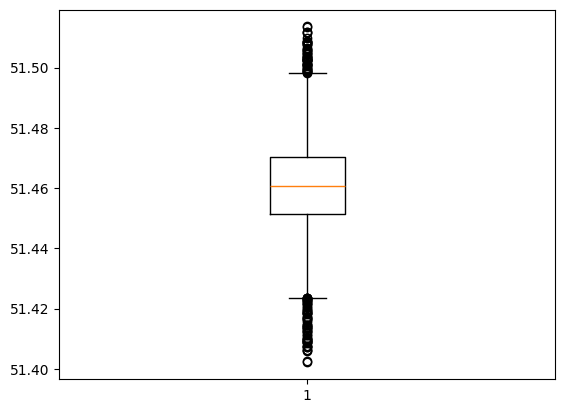

In [70]:
import matplotlib.pyplot as plt
plt.boxplot(x=data['latitude'])
plt.show()

In [71]:
import numpy as np
q1 = np.quantile(data['latitude'], 0.25)
q3 = np.quantile(data['latitude'], 0.75)
iqr = q3-q1
upper_lim = q3+(3*iqr)
lower_lim = q1-(3*iqr)

In [72]:
outliers_1 = data[(data['latitude'] > upper_lim) | (data['latitude'] < lower_lim)]
outliers_1

,id,name,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month


In [73]:
q1 = np.quantile(data['longitude'], 0.25)
q3 = np.quantile(data['longitude'], 0.75)
iqr = q3-q1
upper_lim = q3+(2.75*iqr)
lower_lim = q1-(2.75*iqr)

In [74]:
outliers_2 = data[(data['longitude'] > upper_lim) | (data['longitude'] < lower_lim)]
outliers_2['neighbourhood_cleansed']

,neighbourhood_cleansed
265,Avonmouth & Lawrence Weston


## Mininum/maximum nights

In [75]:
q1 = np.quantile(data['minimum_nights'], 0.25)
q3 = np.quantile(data['minimum_nights'], 0.75)
iqr = q3-q1
upper_lim = q3+(50*iqr)
lower_lim = q1-(50*iqr)

In [76]:
outliers_3 = data[(data['minimum_nights'] > upper_lim) | (data['minimum_nights'] < lower_lim)]
outliers_3['minimum_nights']

,minimum_nights
326,180
440,365
965,182


In [77]:
data = data[~((data['minimum_nights'] > upper_lim) | (data['minimum_nights'] < lower_lim))]

In [78]:
q1 = np.quantile(data['maximum_nights'], 0.25)
q3 = np.quantile(data['maximum_nights'], 0.75)
iqr = q3-q1
upper_lim = q3+(2*iqr)
lower_lim = q1-(2*iqr)

In [79]:
outliers_4 = data[(data['maximum_nights'] > upper_lim) | (data['maximum_nights'] < lower_lim)]
outliers_4['maximum_nights'].unique()

array([1125,  999, 1124, 1121, 1000])

In [80]:
len(outliers_4)

469

In [81]:
#data = data[~((data['maximum_nights'] > upper_lim) | (data['maximum_nights'] < lower_lim))]

## Łazienki i sypialnie

In [82]:
q1 = data['bathrooms'].quantile(0.25)
q3 = data['bathrooms'].quantile(0.75)
iqr = q3-q1
upper_lim = q3+(5*iqr)
lower_lim = q1-(5*iqr)

In [83]:
outliers_5 = data[(data['bathrooms'] > upper_lim) | (data['bathrooms'] < lower_lim)]
outliers_5['bathrooms'].unique()

array([15. ,  4.5,  5. , 10. ,  6. ,  7. ])

In [84]:
#data = data[~((data['bathrooms'] > upper_lim) | (data['bathrooms'] < lower_lim))]

In [85]:
q1 = data['bedrooms'].quantile(0.25)
q3 = data['bedrooms'].quantile(0.75)
iqr = q3-q1
upper_lim = q3+(3*iqr)
lower_lim = q1-(3*iqr)

In [86]:
outliers_5 = data[(data['bedrooms'] > upper_lim) | (data['bedrooms'] < lower_lim)]
outliers_5['bedrooms'].unique()

array([50.,  6.,  8., 14.,  7., 10.,  9.])

In [87]:
len(outliers_5)

26

In [88]:
#data = data[~((data['bedrooms'] > upper_lim) | (data['bedrooms'] < lower_lim))]

# Ammenities

In [89]:
czyste_amenities = data['amenities'].str.replace('", "', '|', regex=False)
czyste_amenities = czyste_amenities.str.replace('[', '', regex=False)
czyste_amenities = czyste_amenities.str.replace(']', '', regex=False)
czyste_amenities = czyste_amenities.str.replace('"', '', regex=False)

amenities_df = czyste_amenities.str.get_dummies(sep='|')
amenities_df.insert(0, 'id', data['id'])
amenities_df.head()

,id,"100 inch HDTV with Amazon Prime Video, Apple TV, Disney+, Netflix","118 inch HDTV with Amazon Prime Video, Apple TV, Netflix",17 inch TV,19 inch TV,22 inch HDTV,"22 inch HDTV with Apple TV, Amazon Prime Video, Disney+, Netflix",22 inch TV,24 inch HDTV,"24 inch HDTV with Chromecast, Disney+, Roku, Apple TV, DVD player",...,Window AC unit,Window guards,Wine glasses,With ice box refrigerator,Yamaha 5.1 in living space & Bose in bedroom Bluetooth sound system,Yamaha sound system with Bluetooth and aux,You may use my fridge for more food refrigerator,ZANUSSI electric stove,Zanussi refrigerator,Zanussi stainless steel electric stove
0,7746625,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,9521652,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,14483722,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
5,15457289,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
6,15724848,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [90]:
columns_to_drop = []
for col in amenities_df.columns:
    if col != 'id' and amenities_df[col].sum() < 100:
        columns_to_drop.append(col)

amenities_filtered_bristol = amenities_df.drop(columns=columns_to_drop)
print(f"Dropped {len(columns_to_drop)} columns.")
amenities_filtered_bristol.head()

Dropped 963 columns.


,id,BBQ grill,Backyard,Baking sheet,Barbecue utensils,Bathtub,Bed linens,Blender,Board games,Body soap,...,Shower gel,Single level home,Smart lock,Smoke alarm,Stove,TV,Toaster,Washer,Wifi,Wine glasses
0,7746625,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,1
1,9521652,0,0,0,0,0,1,0,0,0,...,1,0,0,1,1,1,0,0,1,1
4,14483722,0,0,0,0,0,0,0,0,0,...,1,0,0,1,1,1,1,0,1,1
5,15457289,0,0,0,0,0,1,0,0,1,...,1,0,0,1,1,1,1,0,1,1
6,15724848,0,0,0,0,0,1,0,0,0,...,1,0,0,1,0,1,0,0,1,0


In [91]:
amenities_filtered_bristol.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2202 entries, 0 to 2844
Data columns (total 94 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   id                                      2202 non-null   int64
 1   BBQ grill                               2202 non-null   int64
 2   Backyard                                2202 non-null   int64
 3   Baking sheet                            2202 non-null   int64
 4   Barbecue utensils                       2202 non-null   int64
 5   Bathtub                                 2202 non-null   int64
 6   Bed linens                              2202 non-null   int64
 7   Blender                                 2202 non-null   int64
 8   Board games                             2202 non-null   int64
 9   Body soap                               2202 non-null   int64
 10  Books and reading material              2202 non-null   int64
 11  Breakfast             

In [92]:
amenities_filtered_bristol.to_csv('amenities_filtered_bristol.csv', index=False)

# Konwersja typów

In [93]:
data['price'] = data['price'].str.replace(',', '', regex=False)
data['price'] = data['price'].str.replace('$', '', regex=False)
data['price'] = data['price'].astype(float)

In [94]:
data['price']

,price
0,378.0
1,76.0
4,57.0
5,61.0
6,87.0
...,...
2840,140.0
2841,132.0
2842,113.0
2843,160.0


In [95]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2202 entries, 0 to 2844
Data columns (total 57 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            2202 non-null   int64  
 1   name                                          2202 non-null   object 
 2   host_id                                       2202 non-null   int64  
 3   host_name                                     2202 non-null   object 
 4   host_since                                    2202 non-null   object 
 5   host_location                                 1746 non-null   object 
 6   host_about                                    1297 non-null   object 
 7   host_response_time                            2048 non-null   object 
 8   host_response_rate                            2048 non-null   object 
 9   host_acceptance_rate                          2102 non-null   object

In [96]:
data = data.drop(columns=['amenities'])

In [97]:
data['host_response_rate'].unique()

array([nan, '100%', '50%', '90%', '80%', '60%', '0%', '94%', '67%', '86%',
       '96%', '97%', '93%', '55%', '33%', '88%', '83%', '44%', '99%',
       '70%', '75%', '73%', '13%', '20%', '40%', '43%', '10%', '46%',
       '30%', '57%', '81%', '98%', '95%', '92%', '89%', '79%', '77%',
       '91%', '17%', '62%'], dtype=object)

In [98]:
data['host_response_rate'] = data['host_response_rate'].str.replace('%', '', regex=False).astype(float)
data['host_response_rate'] = data['host_response_rate'].apply(lambda x: x/100)

In [99]:
data['host_response_rate'].fillna(0, inplace=True)

/tmp/ipykernel_221/3073513857.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['host_response_rate'].fillna(0, inplace=True)


In [100]:
data['host_acceptance_rate'] = data['host_acceptance_rate'].str.replace('%', '', regex=False).astype(float)
data['host_acceptance_rate'] = data['host_acceptance_rate'].apply(lambda x: x/100)

In [101]:
data['host_acceptance_rate'].fillna(0, inplace=True)
data['host_acceptance_rate'].unique()

/tmp/ipykernel_221/1208224072.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['host_acceptance_rate'].fillna(0, inplace=True)


array([0.  , 1.  , 0.86, 0.95, 0.92, 0.97, 0.78, 0.9 , 0.77, 0.98, 0.96,
       0.91, 0.5 , 0.31, 0.72, 0.64, 0.89, 0.69, 0.4 , 0.75, 0.83, 0.39,
       0.67, 0.94, 0.82, 0.43, 0.14, 0.93, 0.79, 0.99, 0.18, 0.27, 0.74,
       0.54, 0.6 , 0.17, 0.76, 0.09, 0.88, 0.8 , 0.35, 0.58, 0.65, 0.66,
       0.55, 0.44, 0.87, 0.81, 0.25, 0.49, 0.84, 0.29, 0.51, 0.57, 0.23,
       0.33, 0.7 , 0.71, 0.73, 0.85, 0.46, 0.08, 0.61, 0.36, 0.2 , 0.56,
       0.63, 0.41, 0.15, 0.37, 0.68, 0.13, 0.62, 0.42, 0.28, 0.22, 0.52,
       0.05, 0.45, 0.11, 0.19])

In [102]:
data['host_identity_verified'].unique()

array(['f', 't'], dtype=object)

In [103]:
cols_to_convert = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified','has_availability','instant_bookable']

In [104]:
for col in cols_to_convert:
    data[col] = data[col].replace({'t': True, 'f': False, 'True': True, 'False': False, 'TRUE': True, 'FALSE': False})
    data[col] = data[col].fillna(False)
    data[col] = data[col].astype(int)

/tmp/ipykernel_221/4011864632.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].fillna(False)
/tmp/ipykernel_221/4011864632.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].replace({'t': True, 'f': False, 'True': True, 'False': False, 'TRUE': True, 'FALSE': False})
/tmp/ipykernel_221/4011864632.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to 

In [105]:
data['instant_bookable'].unique()

array([0, 1])

In [106]:
data['id'] = data['id'].astype(int)
data['host_id'] = data['host_id'].astype(str)

In [107]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2202 entries, 0 to 2844
Data columns (total 56 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            2202 non-null   int64  
 1   name                                          2202 non-null   object 
 2   host_id                                       2202 non-null   object 
 3   host_name                                     2202 non-null   object 
 4   host_since                                    2202 non-null   object 
 5   host_location                                 1746 non-null   object 
 6   host_about                                    1297 non-null   object 
 7   host_response_time                            2048 non-null   object 
 8   host_response_rate                            2202 non-null   float64
 9   host_acceptance_rate                          2202 non-null   float6

In [108]:
data = data.replace(to_replace=[r'\r\n', r'\n', r'\r'], value=' ', regex=True)

In [109]:
numeryczne = data.select_dtypes(include='number')
numeryczne.head()

,id,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,7746625,0.0,0.00,0,1,1,1,0,51.477523,-2.606324,...,5.00,4.75,5.00,4.50,0,1,1,0,0,0.11
1,9521652,1.0,1.00,1,3,3,1,1,51.454400,-2.594040,...,4.90,4.96,4.97,4.77,1,3,3,0,0,4.02
4,14483722,1.0,0.86,0,4,5,1,1,51.466310,-2.581050,...,4.73,4.72,4.12,4.28,0,4,4,0,0,0.76
5,15457289,1.0,0.86,0,4,5,1,1,51.467380,-2.580570,...,4.77,4.70,4.11,4.23,0,4,4,0,0,0.49
6,15724848,1.0,1.00,0,1,1,1,1,51.465672,-2.604677,...,5.00,5.00,4.96,4.96,0,1,1,0,0,0.21


In [110]:
for col in numeryczne:
  data[col] = data[col].astype(str)
  data[col] = data[col].str.replace('.', ',', regex=False)

In [111]:
data['host_response_rate'].head()

,host_response_rate
0,"0,0"
1,"1,0"
4,"1,0"
5,"1,0"
6,"1,0"


In [112]:
data.to_csv('bristol_cleaned.csv', index=False)